# HAM10000 – Version Clinique EfficientNetB3 + Focal Loss

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.20.0


In [2]:
base_dir = os.getcwd()

metadata_path = os.path.join(base_dir+'/data', "HAM10000_metadata.csv")
img_dir_1 = os.path.join(base_dir+'/data', "HAM10000_images_part_1")
img_dir_2 = os.path.join(base_dir+'/data', "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

In [3]:
print(df.shape)
print(df.columns)
df.info()

print("\nRépartition des classes (dx) :")
print(df['dx'].value_counts())


(10015, 7)
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB

Répartition des classes (dx) :
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [4]:
df.info()
df.isna().sum()
df['age'].describe()
df['sex'].value_counts()
df['localization'].value_counts()
df['dx'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [5]:
import os

base_dir = os.getcwd()
img_dir_1 = os.path.join(base_dir, 'data', 'HAM10000_images_part_1')
img_dir_2 = os.path.join(base_dir, 'data', 'HAM10000_images_part_2')
img_dir_sup = os.path.join(base_dir, 'data', 'HAM10000_images_sup')

def get_image_path(image_id):
    filename = image_id + ".jpg"
    path1 = os.path.join(img_dir_1, filename)
    path2 = os.path.join(img_dir_2, filename)
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None   # Image introuvable

df["file_path"] = df["image_id"].apply(get_image_path)

print("Images introuvables :", df["file_path"].isna().sum())
df.head()


Images introuvables : 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,file_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/home/arnauld/code/Cromyz/project_dermai_assis...


In [6]:
import pandas as pd

lesion_df = df.groupby('lesion_id')['dx'].first().reset_index()
lesion_df.head()
print(lesion_df.shape)


(7470, 2)


In [7]:
# Compter le nombre de lésions uniques par type
unique_lesions_by_dx = df.groupby("dx")["lesion_id"].nunique()

print(unique_lesions_by_dx)

dx
akiec     228
bcc       327
bkl       727
df         73
mel       614
nv       5403
vasc       98
Name: lesion_id, dtype: int64


In [8]:
# Si ce n'est pas déjà fait : on garde 1 image par lesion_id
df_unique = df.drop_duplicates(subset='lesion_id').copy()
print(df_unique.shape)

(7470, 8)


In [ ]:
img_dir_2 = os.path.join(base_dir, 'data', 'HAM10000_images_sup')

In [10]:
import os
from PIL import Image, ImageOps
import pandas as pd

# 1) Dossier pour stocker les images miroir
img_dir_sup = os.path.join(base_dir, 'data', 'HAM10000_images_sup')
os.makedirs(img_dir_sup, exist_ok=True)

# 2) Une image unique par lésion
df_unique = df.drop_duplicates(subset='lesion_id').copy()

# 3) On filtre les dx ≠ nv
df_to_mirror = df_unique[df_unique['dx'] != 'nv'].copy()

augmented_rows = []

# 4) Générer les images miroirs + nouvelles entrées metadata
for _, row in df_to_mirror.iterrows():
    src_path = row['file_path']
    try:
        img = Image.open(src_path)
    except Exception as e:
        print(f"❌ Impossible d'ouvrir {src_path} : {e}")
        continue

    # Miroir horizontal
    img_mirror = ImageOps.mirror(img)

    # ---- Nouveau image_id ----
    new_image_id = row['image_id'] + "_mirror"

    # ---- Nouveau lesion_id ----
    new_lesion_id = row['lesion_id'] + "_mirror"

    # ---- Nouveau chemin de fichier ----
    new_filename = new_image_id + ".jpg"
    dst_path = os.path.join(img_dir_sup, new_filename)

    # Sauvegarde image miroir
    img_mirror.save(dst_path)

    # ---- Création nouvelle ligne metadata ----
    new_row = row.copy()
    new_row['image_id'] = new_image_id
    new_row['file_path'] = dst_path
    new_row['lesion_id'] = new_lesion_id
    new_row['aug_type'] = 'mirror'

    augmented_rows.append(new_row)

# DataFrame des nouvelles images
df_mirror = pd.DataFrame(augmented_rows)

# 5) Création du DF final : original + miroir
df_aug = pd.concat([df, df_mirror], ignore_index=True)

# 6) Sauvegarde dans CSV
output_csv = os.path.join(base_dir, 'data', 'HAM10000_metadata_aug.csv')
df_aug.to_csv(output_csv, index=False)

print("✅ Fichier metadata créé :", output_csv)
print("Taille finale :", df_aug.shape)
print(df_aug.tail())



✅ Fichier metadata créé : /home/arnauld/code/Cromyz/project_dermai_assist/notebooks/data/HAM10000_metadata_aug.csv
Taille finale : (12082, 9)
                lesion_id             image_id     dx dx_type   age     sex  \
12077  HAM_0000193_mirror  ISIC_0030877_mirror  akiec   histo  60.0  female   
12078  HAM_0000020_mirror  ISIC_0031922_mirror  akiec   histo  60.0  female   
12079  HAM_0005579_mirror  ISIC_0029309_mirror  akiec   histo  80.0    male   
12080  HAM_0001576_mirror  ISIC_0033705_mirror  akiec   histo  60.0    male   
12081  HAM_0002867_mirror  ISIC_0033084_mirror  akiec   histo  40.0    male   

      localization                                          file_path aug_type  
12077         face  /home/arnauld/code/Cromyz/project_dermai_assis...   mirror  
12078         face  /home/arnauld/code/Cromyz/project_dermai_assis...   mirror  
12079         face  /home/arnauld/code/Cromyz/project_dermai_assis...   mirror  
12080         face  /home/arnauld/code/Cromyz/project_derma

In [11]:
df_aug.groupby("dx")["lesion_id"].nunique()

dx
akiec     456
bcc       654
bkl      1454
df        146
mel      1228
nv       5403
vasc      196
Name: lesion_id, dtype: int64

In [ ]:
angles = [45, 90, 135]
new_rows = []

for _, row in df_rep.iterrows():
    orig_path = row['file_path']
    
    if not os.path.exists(orig_path):
        print(f"Fichier introuvable, on saute : {orig_path}")
        continue
    
    try:
        img = Image.open(orig_path)
    except Exception as e:
        print(f"Impossible d'ouvrir {orig_path} : {e}")
        continue
    
    base_lesion_id = row['lesion_id']
    base_image_id = row['image_id']
    ext = os.path.splitext(orig_path)[1]  # typiquement '.jpg'
    
    for angle in angles:
        # rotation
        img_rot = img.rotate(angle, expand=True)
        
        # nouveaux IDs
        new_lesion_id = f"{base_lesion_id}_rot{angle}"
        new_image_id = f"{base_image_id}_rot{angle}"
        new_filename = new_image_id + ext
        new_path = os.path.join(img_dir_sup, new_filename)
        
        # sauvegarde
        img_rot.save(new_path)
        
        # nouvelle ligne de metadata
        new_row = row.copy()
        new_row['lesion_id'] = new_lesion_id
        new_row['image_id'] = new_image_id
        new_row['file_path'] = new_path
        
        new_rows.append(new_row)

len(new_rows)


In [3]:
def resolve_path(image_id):
    fname = image_id + ".jpg"
    p1 = os.path.join(img_dir_1, fname)
    p2 = os.path.join(img_dir_2, fname)
    if os.path.exists(p1):
        return p1
    elif os.path.exists(p2):
        return p2
    else:
        return None

df["image_path"] = df["image_id"].apply(resolve_path)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/home/arnauld/code/Cromyz/project_dermai_assis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/home/arnauld/code/Cromyz/project_dermai_assis...


In [4]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = list(label_encoder.classes_)
class_names

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [5]:
train_df, tmp_df = train_test_split(
    df, test_size=0.40, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=42
)

print("Train :", train_df.shape, "Val :", val_df.shape, "Test :", test_df.shape)

Train : (6009, 9) Val : (2003, 9) Test : (2003, 9)


In [6]:
IMAGE_SIZE = 300
CHANNELS = 3
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

I0000 00:00:1763732156.432263   42231 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4608 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:02:00.0, compute capability: 8.9


In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = preprocess_input(img)
    return img, label

In [8]:
def make_dataset(df_part, shuffle=False):
    paths = df_part["image_path"].values
    labels = df_part["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_part), reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

In [9]:
alpha_np = np.array([
    2.0,  # akiec - malin
    1.8,  # bcc   - malin mais moins agressif
    0.7,  # bkl   - bénin (on baisse pour limiter les confusions)
    3.0,  # df    - bénin mais très rare → on remonte
    2.5,  # mel   - MELANOME : toujours la priorité n°1
    0.5,  # nv    - très fréquent, on le pénalise encore un peu
    3.0   # vasc  - rare, on veut remonter son rappel
], dtype="float32")

alpha = tf.constant(alpha_np, dtype=tf.float32)
print("Alpha clinique v2 :", alpha_np)


def categorical_focal_loss(alpha, gamma=1.5):
    alpha = tf.reshape(alpha, (1, -1))

    def loss(y_true, y_pred):
        # y_true : indices entiers [0..6]
        y_true_oh = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=len(class_names)
        )
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow((1.0 - y_pred), gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=1)

    return loss


loss_fn = categorical_focal_loss(alpha=alpha, gamma=1.5)


Alpha clinique v2 : [2.  1.8 0.7 3.  2.5 0.5 3. ]


In [10]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE,
    pooling="avg"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        10,759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,794,294 (41.18 MB)

 Trainable params: 10,759 (42.03 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

In [12]:
EPOCHS = 7
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 60s 134ms/step - accuracy: 0.4527 - loss: 1.1369 - val_accuracy: 0.5871 - val_loss: 0.9851
Epoch 2/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.5803 - loss: 0.9325 - val_accuracy: 0.6056 - val_loss: 0.8864
Epoch 3/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.5996 - loss: 0.8569 - val_accuracy: 0.5961 - val_loss: 0.8197
Epoch 4/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - accuracy: 0.6098 - loss: 0.8066 - val_accuracy: 0.6261 - val_loss: 0.7794
Epoch 5/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 48s 125ms/step - accuracy: 0.6297 - loss: 0.7549 - val_accuracy: 0.6271 - val_loss: 0.7486
Epoch 6/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - accuracy: 0.6279 - loss: 0.7314 - val_accuracy: 0.6480 - val_loss: 0.7255
Epoch 7/7
376/376 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - accuracy: 0.6450 - loss: 0.7165 - val_accuracy: 0.6136 - val_loss: 0.7124


In [13]:
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true.append(batch_y.numpy())
    y_pred.append(np.argmax(preds, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names, digits=2))

              precision    recall  f1-score   support

       akiec       0.32      0.20      0.24        66
         bcc       0.47      0.16      0.23       103
         bkl       0.67      0.16      0.25       219
          df       0.00      0.00      0.00        23
         mel       0.23      0.78      0.35       223
          nv       0.90      0.73      0.81      1341
        vasc       0.33      0.29      0.31        28

    accuracy                           0.61      2003
   macro avg       0.42      0.33      0.31      2003
weighted avg       0.74      0.61      0.63      2003



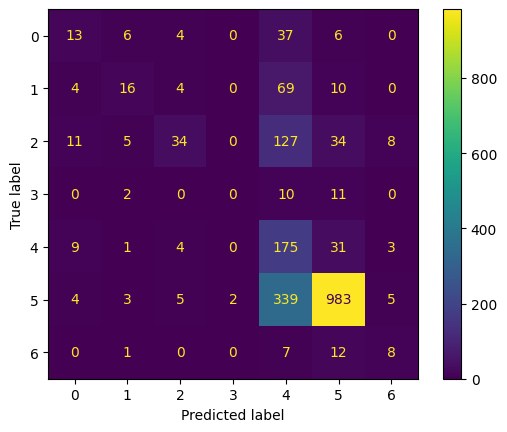

In [14]:
# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace y_true and y_pred with your actual variables
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [15]:
# === Phase 2 : Fine-Tuning EfficientNetB3 ===

# 1) On dé-gèle une partie du backbone
#    → ici, on dé-gèle les ~80 dernières couches pour être un peu plus agressif
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

# 2) Optimiseur avec LR très basse pour le FT
optimizer_ft = tf.keras.optimizers.Adam(learning_rate=5e-6)

# 3) Métriques "safe" (pas de Precision/Recall Keras ici)
metrics_ft = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc")
]

model.compile(
    optimizer=optimizer_ft,
    loss=loss_fn,          # ta focal loss
    metrics=metrics_ft
)

# 4) Callbacks pour stabiliser le FT
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_acc",     # on surveille la métrique de val
        patience=3,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# 5) Entraînement de fine-tuning
EPOCHS_FT = 10  # ton plan initial

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/10


E0000 00:00:1763732689.368786   42231 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


376/376 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - acc: 0.3874 - loss: 1.1236 - val_acc: 0.5142 - val_loss: 0.8672 - learning_rate: 5.0000e-06
Epoch 2/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - acc: 0.5865 - loss: 0.8377 - val_acc: 0.5836 - val_loss: 0.7705 - learning_rate: 5.0000e-06
Epoch 3/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - acc: 0.6271 - loss: 0.7609 - val_acc: 0.6016 - val_loss: 0.7291 - learning_rate: 5.0000e-06
Epoch 4/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 153ms/step - acc: 0.6459 - loss: 0.7053 - val_acc: 0.6216 - val_loss: 0.6887 - learning_rate: 5.0000e-06
Epoch 5/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 153ms/step - acc: 0.6707 - loss: 0.6610 - val_acc: 0.6326 - val_loss: 0.6604 - learning_rate: 5.0000e-06
Epoch 6/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - acc: 0.6717 - loss: 0.6388 - val_acc: 0.6385 - val_loss: 0.6374 - learning_rate: 5.0000e-06
Epoch 7/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - acc: 0.6858 - loss: 0.5976 - val_acc: 0.6510 - val_loss: 0.6

In [16]:
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true.append(batch_y.numpy())
    y_pred.append(np.argmax(preds, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names, digits=2))

              precision    recall  f1-score   support

       akiec       0.45      0.26      0.33        66
         bcc       0.53      0.57      0.55       103
         bkl       0.64      0.22      0.33       219
          df       0.50      0.09      0.15        23
         mel       0.26      0.79      0.39       223
          nv       0.93      0.73      0.82      1341
        vasc       0.40      0.61      0.48        28

    accuracy                           0.65      2003
   macro avg       0.53      0.47      0.43      2003
weighted avg       0.78      0.65      0.68      2003



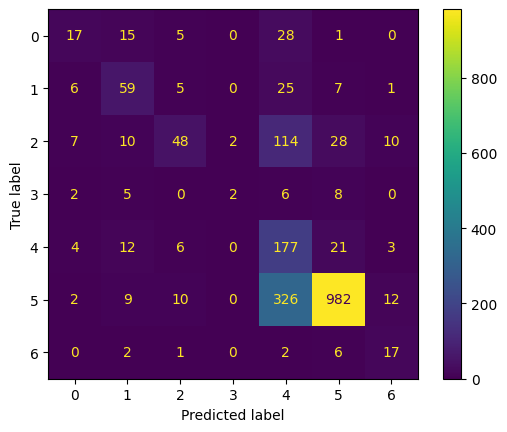

In [17]:
# --- Confusion Matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace y_true and y_pred with your actual variables
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


# Save the Model

In [36]:
model.save("dermai_efficientnetB3_finetuned_Arnauld.keras")

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# ------------------------------------------------------------------
# 1) Compute classification report with class_names as target_names
# ------------------------------------------------------------------
# y_true : true labels on test set (integers 0..6)
# y_pred : predicted labels on test set (integers 0..6)
# class_names : list of class labels in the correct order

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# ------------------------------------------------------------------
# 2) Clinical metadata for each HAM10000 class
# ------------------------------------------------------------------
scientific_names_en = {
    "akiec": "Actinic Keratoses / Intraepithelial Carcinoma",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis-like Lesions",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevus",
    "vasc":  "Vascular Lesions",
}

clinical_type = {
    "akiec": "malignant (non-melanoma, aggressive)",
    "bcc":   "malignant (non-melanoma, locally invasive)",
    "bkl":   "benign, polymorphic",
    "df":    "benign, rare",
    "mel":   "malignant (melanoma, high risk)",
    "nv":    "benign, very frequent",
    "vasc":  "benign, rare / special patterns",
}

# ------------------------------------------------------------------
# 3) Helper to generate ML analysis text
# ------------------------------------------------------------------
def generate_ml_analysis(label, p, r, s, ctype):
    """
    label : class label (e.g. 'mel')
    p : precision  [0..1]
    r : recall     [0..1]
    s : support    (int)
    ctype : clinical type string
    """
    comments = []

    # Data volume effect
    if s < 40:
        comments.append("Very few samples → metrics are unstable and prone to variance.")

    # Malignant classes: focus on recall
    if "malignant" in ctype:
        if r < 0.70:
            comments.append("Recall is too low for a malignant class → risk of missing dangerous lesions.")
        else:
            comments.append("Recall is high for a malignant class → clinically safer (few missed lesions).")

    # High recall, low precision
    if p < 0.40 and r >= 0.70:
        comments.append("Model is tuned for high recall at the expense of precision → many false positives.")
    
    # High precision, low recall
    if p >= 0.70 and r < 0.50:
        comments.append("High precision but low recall → model detects mainly the easiest cases and misses subtle ones.")
    
    # Benign, frequent classes
    if "benign" in ctype and "frequent" in ctype and p > 0.80 and r > 0.70:
        comments.append("Frequent benign class is handled well → limited clinical risk.")

    # Polymorphic / confusing lesions
    if "polymorphic" in ctype and r < 0.40:
        comments.append("Strong visual variability → model struggles to generalize across all patterns.")

    # If nothing special triggered
    if not comments:
        comments.append("Balanced but still improvable trade-off between false positives and false negatives.")

    return " ".join(comments)

# ------------------------------------------------------------------
# 4) Build the per-class DataFrame
# ------------------------------------------------------------------
rows = []

for label in class_names:
    # On suppose que le report utilise les labels textuels (via target_names)
    metrics = report[label]
    p = metrics["precision"]   # precision (0..1)
    r = metrics["recall"]      # recall (0..1)
    s = metrics["support"]     # support (n)

    correct_pct = r * 100.0             # % of true class correctly detected  (sensitivity)
    wrong_pct   = (1.0 - r) * 100.0     # % of true class missed              (1 - recall)

    ml_analysis = generate_ml_analysis(
        label=label,
        p=p,
        r=r,
        s=s,
        ctype=clinical_type[label]
    )

    rows.append({
        "Label": label,
        "Scientific name (EN)": scientific_names_en[label],
        "Clinical type": clinical_type[label],
        "Precision (%)": p * 100.0,
        "Recall (%)": r * 100.0,
        "Correct detections (%)": correct_pct,
        "Wrong detections (%)": wrong_pct,
        "Support (n)": float(s),
        "ML Analysis": ml_analysis,
    })

df_classes = pd.DataFrame(rows)

# ------------------------------------------------------------------
# 5) Styling: 2 decimals + color gradients + highlight malignant
# ------------------------------------------------------------------
# Numerical formatting
fmt_cols = [
    "Precision (%)",
    "Recall (%)",
    "Correct detections (%)",
    "Wrong detections (%)",
    "Support (n)",
]

def highlight_malignant(row):
    """Light red background for malignant classes."""
    style = [""] * len(row)
    if "malignant" in row["Clinical type"]:
        style = ["background-color: rgba(255, 0, 0, 0.08);"] * len(row)
    return style

styled = (
    df_classes
    .style
    .format({col: "{:.2f}" for col in fmt_cols})
    .apply(highlight_malignant, axis=1)
    .background_gradient(
        subset=["Precision (%)", "Recall (%)", "Correct detections (%)"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Wrong detections (%)"],
        cmap="Reds"
    )
    .set_properties(
        subset=["Label"],
        **{"font-weight": "bold"}
    )
)

styled



,Label,Scientific name (EN),Clinical type,Precision (%),Recall (%),Correct detections (%),Wrong detections (%),Support (n),ML Analysis
0,akiec,Actinic Keratoses / Intraepithelial Carcinoma,"malignant (non-melanoma, aggressive)",44.74,25.76,25.76,74.24,66.00,Recall is too low for a malignant class → risk of missing dangerous lesions.
1,bcc,Basal Cell Carcinoma,"malignant (non-melanoma, locally invasive)",52.68,57.28,57.28,42.72,103.00,Recall is too low for a malignant class → risk of missing dangerous lesions.
2,bkl,Benign Keratosis-like Lesions,"benign, polymorphic",64.00,21.92,21.92,78.08,219.00,Strong visual variability → model struggles to generalize across all patterns.
3,df,Dermatofibroma,"benign, rare",50.00,8.70,8.70,91.30,23.00,Very few samples → metrics are unstable and prone to variance.
4,mel,Melanoma,"malignant (melanoma, high risk)",26.11,79.37,79.37,20.63,223.00,Recall is high for a malignant class → clinically safer (few missed lesions). Model is tuned for high recall at the expense of precision → many false positives.
5,nv,Melanocytic Nevus,"benign, very frequent",93.26,73.23,73.23,26.77,1341.00,Frequent benign class is handled well → limited clinical risk.
6,vasc,Vascular Lesions,"benign, rare / special patterns",39.53,60.71,60.71,39.29,28.00,Very few samples → metrics are unstable and prone to variance.
